In [1]:
import pandas as pd

In [2]:
# load the dataset
df = pd.read_csv('./output/04_imdb.csv')

In [3]:
# print columns list
print(df.columns)

Index(['originalTitle', 'rating', 'numVotes', 'totalCredits',
       'criticReviewsTotal', 'titleType', 'userReviewsTotal', 'castNumber',
       'companiesNumber', 'averageRating', 'writerCredits', 'directorsCredits',
       'quotesTotal', 'startYearDecade', 'totalMedia', 'totalRecognitions',
       'runtimeHours', 'genreFamily', 'genreDocumentary', 'genreNews',
       'genreFilm-Noir', 'genreWestern', 'genreFantasy', 'genreAdult',
       'genreAction', 'genreMusic', 'genreComedy', 'genreSport', 'genreHorror',
       'genreShort', 'genreBiography', 'genreTalk-Show', 'genreDrama',
       'genreRomance', 'genreWar', 'genreMystery', 'genreHistory',
       'genreSci-Fi', 'genreAnimation', 'genreAdventure', 'genreReality-TV',
       'genreMusical', 'genreThriller', 'genreGame-Show', 'genreCrime'],
      dtype='object')


In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
# split the data into train and test sets
train_df, test_df = train_test_split(df, test_size = 0.25, random_state=42)

# check the shape of the train and test sets
print(f"Train set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")

Train set shape: (108884, 45)
Test set shape: (36295, 45)


In [5]:
columns_to_filter = [
    'numVotes', 
    'totalCredits',
    'criticReviewsTotal', 
    'userReviewsTotal', 
    'castNumber',
    'companiesNumber',
    'writerCredits',
#    'directorsCredits',
    'quotesTotal',
    'totalMedia',
    'totalRecognitions',
    'runtimeHours'
]
def create_stats_df(df, columns_to_filter):
    """
    Create a DataFrame with statistics (min, max, mean, std) for specified columns.

    Parameters:
    - df: pandas DataFrame
    - columns_to_filter: list of str, columns to filter

    Returns:
    - stats_df: pandas DataFrame with statistics
    """
    stats_list = []  # Usa una lista per raccogliere i dati
    for col in columns_to_filter:
        if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
            min_val = df[col].min()
            max_val = df[col].max()
            mean_val = df[col].mean()
            std_val = df[col].std()
            stats_list.append({'name_col': col, 'min': min_val, 'max': max_val,
                               'mean': mean_val, 'std': std_val})
        else:
            print(f"Column '{col}' is missing or not numeric.")
    
    # Crea il DataFrame dai dati raccolti
    stats_df = pd.DataFrame(stats_list)
    return stats_df

# Esegui la funzione
print(create_stats_df(train_df, columns_to_filter))

              name_col  min        max         mean           std
0             numVotes  5.0  2947931.0  1108.174865  19569.043366
1         totalCredits  0.0    17967.0    58.591161    147.566435
2   criticReviewsTotal  0.0      628.0     2.239943     14.129255
3     userReviewsTotal  0.0    11289.0     5.751717     70.675062
4           castNumber  0.0     8454.0    19.830453     82.885533
5      companiesNumber  0.0      570.0     5.942315     20.291544
6        writerCredits  0.0       51.0     2.035083      2.485009
7          quotesTotal  0.0     1084.0     1.084209      7.507555
8           totalMedia  0.0    20589.0    10.062599    112.685838
9    totalRecognitions  0.0      893.0     0.747520      7.265294
10        runtimeHours  0.0       87.0     0.905066      0.759504


In [6]:
# add column outlier to train_df
# the column is 1 if the row is an outlier for at least one of the columns in columns_to_filter
def add_outlier_column(df, columns_to_filter, tr=6):
    """
    Add an 'outlier' column to the DataFrame based on specified columns.

    Parameters:
    - df: pandas DataFrame
    - columns_to_filter: list of str, columns to filter
    - tr: float, threshold for outliers (default is 5)

    Returns:
    - df: pandas DataFrame with the 'outlier' column added
    """
    # Create a copy of the DataFrame to avoid modifying the original
    df_copy = df.copy()

    # Initialize the 'outlier' column to 0
    df_copy['outlier'] = 0

    # Iterate through each specified column
    for col in columns_to_filter:
        if col in df_copy.columns and pd.api.types.is_numeric_dtype(df_copy[col]):
            # Compute mean and standard deviation after removing zeros
            mean = df_copy[df_copy[col] != 0][col].mean()
            std = df_copy[df_copy[col] != 0][col].std()
            # Compute the first and third quartiles
            q1 = df_copy[df_copy[col] != 0][col].quantile(0.25)
            q3 = df_copy[df_copy[col] != 0][col].quantile(0.75)
            # Compute the interquartile range
            iqr = q3 - q1
            # Calculate the threshold for outliers
            threshold = mean + tr * iqr

            # Mark rows as outliers if they exceed the threshold
            df_copy.loc[df_copy[col] > threshold, 'outlier'] = 1

    return df_copy



In [7]:
tr = 5
# print percentage of outliers
train_df_outliers = add_outlier_column(train_df, columns_to_filter, tr=tr)
# calculate the percentage of outliers
percentage_outliers = (train_df_outliers[train_df_outliers['outlier'] == 1].shape[0] / train_df.shape[0]) * 100
print(f"Percentage of outliers: {percentage_outliers:.2f}%")

Percentage of outliers: 10.56%


In [8]:
# drop all outliers
train_df = train_df_outliers[train_df_outliers['outlier'] == 0]
# drop the outlier column
train_df = train_df.drop(columns=['outlier'])

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_column_distribution(df, column_name,
                             stored_path=None):
    """
    Plots the distribution of a specified column as percentages.

    Parameters:
    - df: pandas DataFrame
    - column_name: str, name of the column to plot
    """

    # Check if the column exists in the DataFrame
    if column_name not in df.columns:
        print(f"Column '{column_name}' not found in the DataFrame.")
        return

    # Set the theme
    sns.set_theme(palette="viridis")

    # Set the figure size
    plt.figure(figsize=(8, 5))

    # Plot the distribution
    df[column_name].value_counts(normalize=True).sort_index().plot(kind='bar')

    # Set the title and labels
    plt.title(f'{column_name.capitalize()} Distribution')
    plt.xlabel(column_name.capitalize())
    plt.ylabel('Percentage')

    # Add labels to the bars
    for i in range(len(df[column_name].value_counts(normalize=True).sort_index())):
        plt.text(i, df[column_name].value_counts(normalize=True).sort_index().iloc[i] + 0.01,
                 f"{df[column_name].value_counts(normalize=True).sort_index().iloc[i]:.2%}",
                 ha='center', va='bottom', fontsize=10)

    # Show the plot
    plt.show()
    if stored_path:
        plt.savefig(stored_path, bbox_inches='tight')
        print(f"Plot saved to {stored_path}")

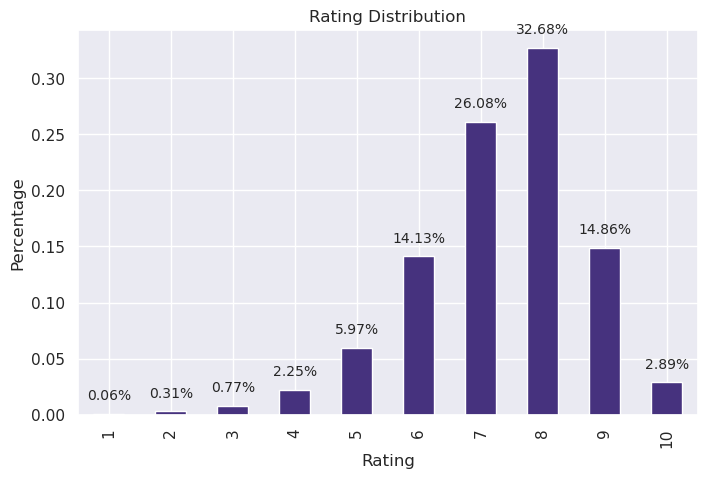

In [10]:
plot_column_distribution(df, 'rating')

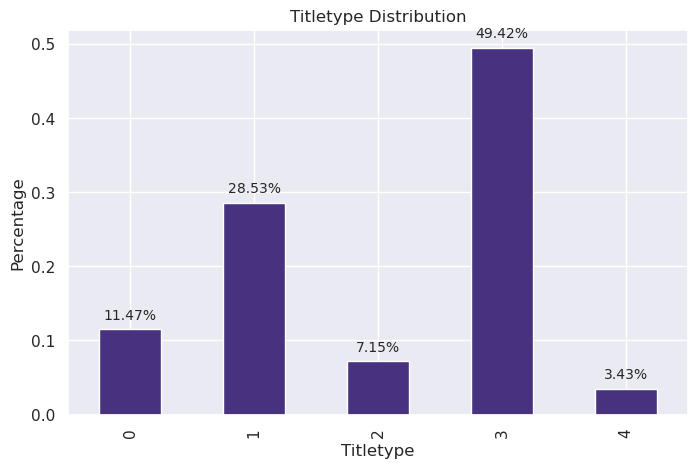

In [11]:
plot_column_distribution(df, 'titleType')

In [12]:
def plot_genre_distribution(df, prefix='genre', figsize=(10, 6)):
    """
    Plots the percentage distribution of columns starting with a specific prefix.

    Parameters:
    - df: pandas DataFrame
    - prefix: str, the prefix to filter columns (default is 'genre')
    - figsize: tuple, the size of the plot (default is (10, 6))
    """
    import matplotlib.pyplot as plt

    # Filter columns that start with the specified prefix
    genre_columns = df.columns[df.columns.str.startswith(prefix)]
    print(genre_columns)

    # Calculate the percentage of '1' for each genre
    genre_dict = {}
    for col in genre_columns:
        genre_name = col.replace(prefix, '')
        genre_dict[genre_name] = df[col].value_counts(normalize=True).get(1, 0)

    # Sort the dictionary by value
    sorted_genre_dict = dict(sorted(genre_dict.items(), key=lambda item: item[1], reverse=True))

    # Plot the sorted dictionary with a barplot
    plt.figure(figsize=figsize)
    plt.barh(list(sorted_genre_dict.keys()), list(sorted_genre_dict.values()))
    plt.xlabel('Percentage of titles by genre')
    plt.ylabel('Genre')
    plt.title(f'Percentage of 1 by {prefix.capitalize()}')
    plt.xticks(rotation=45)

    # Add percentage labels to the bars
    for i in range(len(sorted_genre_dict)):
        plt.text(list(sorted_genre_dict.values())[i] + 0.01, i,
                 f"{list(sorted_genre_dict.values())[i]:.2%}",
                 ha='left', va='center', fontsize=10)

    plt.tight_layout()
    plt.show()

Index(['genreFamily', 'genreDocumentary', 'genreNews', 'genreFilm-Noir',
       'genreWestern', 'genreFantasy', 'genreAdult', 'genreAction',
       'genreMusic', 'genreComedy', 'genreSport', 'genreHorror', 'genreShort',
       'genreBiography', 'genreTalk-Show', 'genreDrama', 'genreRomance',
       'genreWar', 'genreMystery', 'genreHistory', 'genreSci-Fi',
       'genreAnimation', 'genreAdventure', 'genreReality-TV', 'genreMusical',
       'genreThriller', 'genreGame-Show', 'genreCrime'],
      dtype='object')


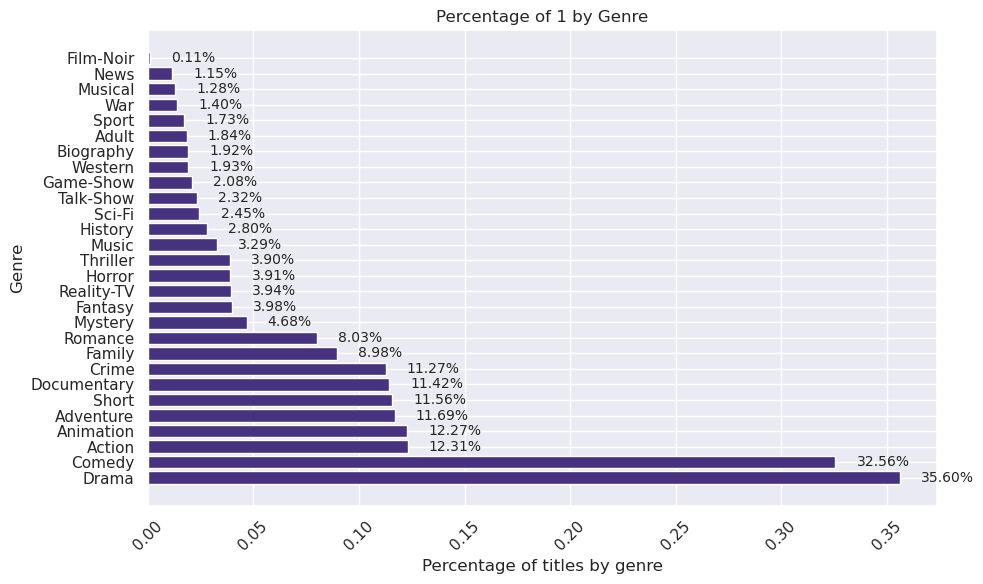

In [13]:
plot_genre_distribution(df)

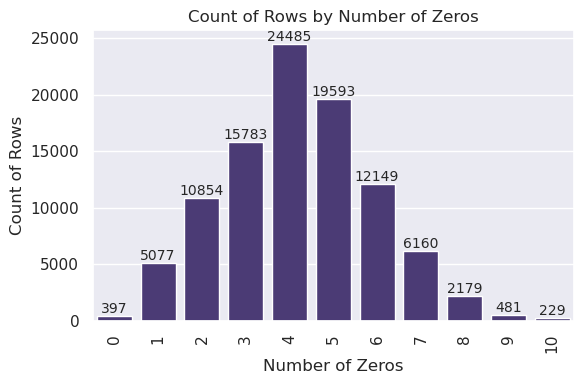

    num_zeros  count
9           0    397
6           1   5077
4           2  10854
2           3  15783
0           4  24485
1           5  19593
3           6  12149
5           7   6160
7           8   2179
8           9    481
10         10    229
Total records: 97387


In [14]:
col_to_use = ['numVotes', 'totalCredits', 'criticReviewsTotal',
       'userReviewsTotal', 'castNumber', 'companiesNumber',
       'writerCredits', 'directorsCredits', 'quotesTotal',
       'totalMedia', 'totalRecognitions']

# count how many zeros are in each row for col_to_check
# then group by the number of zeros and count how many rows have that number of zeros
count_zeros = train_df[col_to_use].apply(lambda x: (x == 0).sum(), axis=1)
count_zeros_counts = count_zeros.value_counts().reset_index()
count_zeros_counts.columns = ['num_zeros', 'count']
# sort by num_zeros
count_zeros_counts.sort_values(by='num_zeros', inplace=True)
# plot the results
plt.figure(figsize=(6, 4))
sns.barplot(data=count_zeros_counts, x='num_zeros', y='count')
plt.title('Count of Rows by Number of Zeros')
plt.xlabel('Number of Zeros')
plt.ylabel('Count of Rows')
plt.xticks(rotation=90)
plt.tight_layout()
# add absolute values on top of the bars
for i in range(len(count_zeros_counts)):
    plt.text(count_zeros_counts['num_zeros'].iloc[i], count_zeros_counts['count'].iloc[i] + 0.01,
             f"{count_zeros_counts['count'].iloc[i]}",
             ha='center', va='bottom', fontsize=10)
plt.show()

# print  a table with number of zeros: number of rows
print(count_zeros_counts)

# print total records by summing count
total_records = count_zeros_counts['count'].sum()
print(f"Total records: {total_records}")


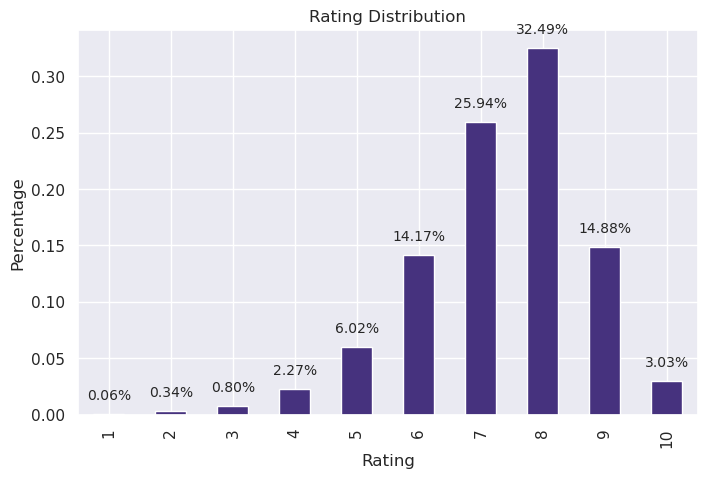

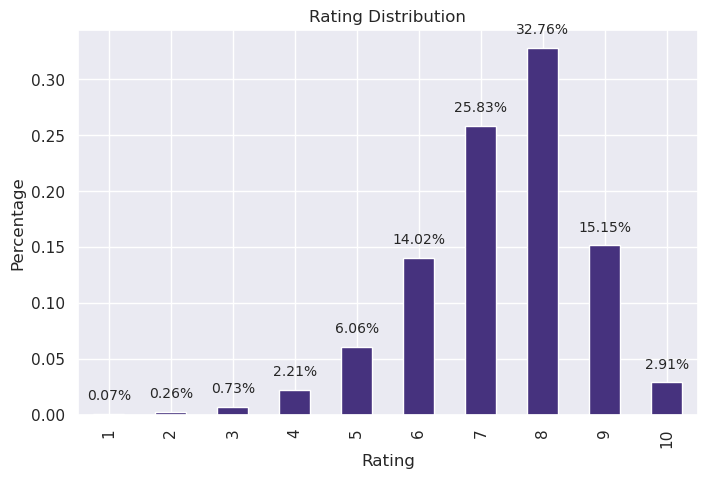

In [15]:
plot_column_distribution(train_df, 'rating')
plot_column_distribution(test_df, 'rating')

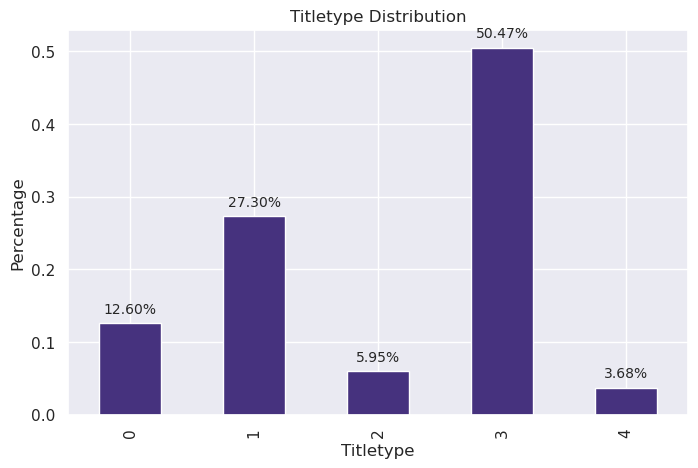

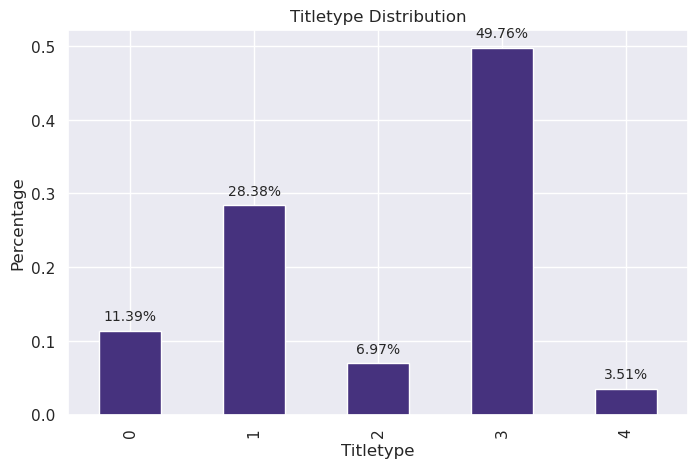

In [16]:
plot_column_distribution(train_df, 'titleType')
plot_column_distribution(test_df, 'titleType')

Index(['genreFamily', 'genreDocumentary', 'genreNews', 'genreFilm-Noir',
       'genreWestern', 'genreFantasy', 'genreAdult', 'genreAction',
       'genreMusic', 'genreComedy', 'genreSport', 'genreHorror', 'genreShort',
       'genreBiography', 'genreTalk-Show', 'genreDrama', 'genreRomance',
       'genreWar', 'genreMystery', 'genreHistory', 'genreSci-Fi',
       'genreAnimation', 'genreAdventure', 'genreReality-TV', 'genreMusical',
       'genreThriller', 'genreGame-Show', 'genreCrime'],
      dtype='object')


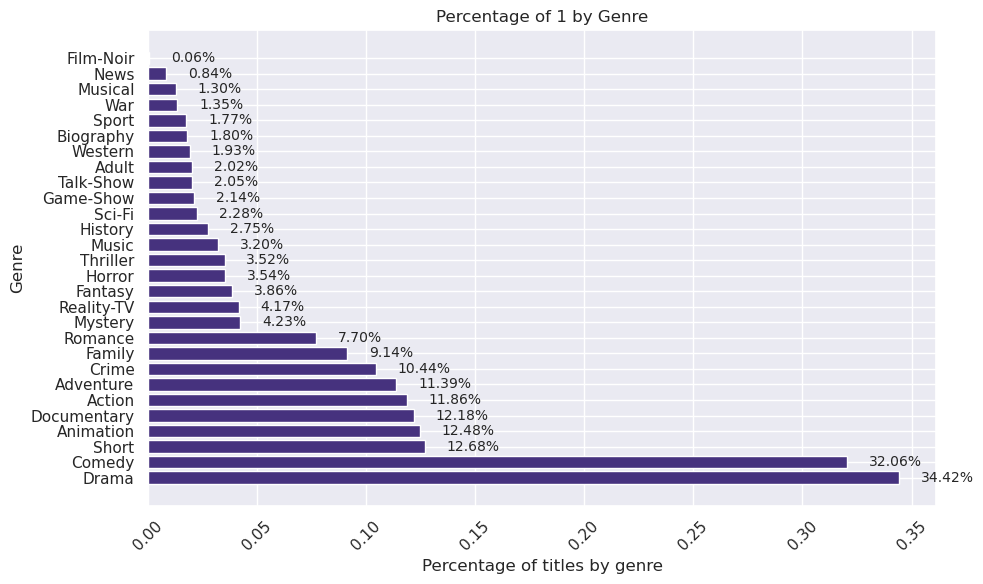

Index(['genreFamily', 'genreDocumentary', 'genreNews', 'genreFilm-Noir',
       'genreWestern', 'genreFantasy', 'genreAdult', 'genreAction',
       'genreMusic', 'genreComedy', 'genreSport', 'genreHorror', 'genreShort',
       'genreBiography', 'genreTalk-Show', 'genreDrama', 'genreRomance',
       'genreWar', 'genreMystery', 'genreHistory', 'genreSci-Fi',
       'genreAnimation', 'genreAdventure', 'genreReality-TV', 'genreMusical',
       'genreThriller', 'genreGame-Show', 'genreCrime'],
      dtype='object')


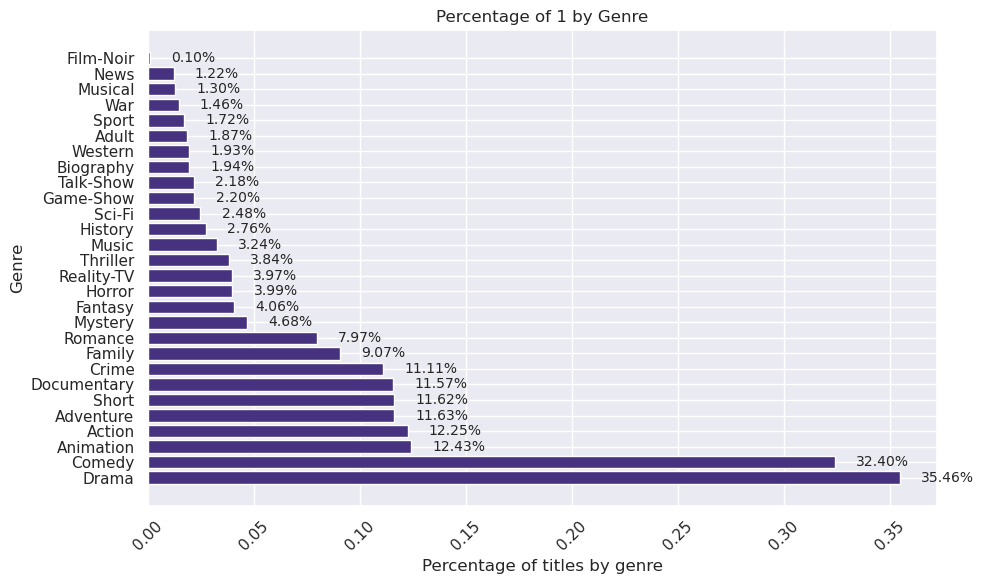

In [17]:
plot_genre_distribution(train_df)
plot_genre_distribution(test_df)

In [18]:
print(train_df.shape)

# drop rows with more than 8 zeros
# print number of rows dropped for each number of zeros
print(f"Number of rows dropped: {len(train_df) - len(train_df[count_zeros < 8])}")
# print percentage of rows dropped
print(f"Percentage of rows dropped: {(len(train_df) - len(train_df[count_zeros < 8])) / len(train_df) * 100:.2f}%")

# print number of rows dropped for each number of zeros
print(f"Number of rows dropped: {len(train_df) - len(train_df[count_zeros <= 8])}")
# print percentage of rows dropped
print(f"Percentage of rows dropped: {(len(train_df) - len(train_df[count_zeros <= 8])) / len(train_df) * 100:.2f}%")
# drop rows with more than 8 zeros
train_df = train_df[count_zeros < 8]

print(train_df.shape)


(97387, 45)
Number of rows dropped: 2889
Percentage of rows dropped: 2.97%
Number of rows dropped: 710
Percentage of rows dropped: 0.73%
(94498, 45)


In [19]:
# dimension of train and test sets
print(f"Train set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")

Train set shape: (94498, 45)
Test set shape: (36295, 45)


In [20]:
# create train and test copy without the originalTitle column
train_df_copy = train_df.copy()
test_df_copy = test_df.copy()

# drop the originalTitle column
train_df_copy.drop(columns=['originalTitle'], inplace=True)
test_df_copy.drop(columns=['originalTitle'], inplace=True)

# save datasets
train_df_copy.to_csv('../train_set/train_no_title.csv', index=False)
test_df_copy.to_csv('../test_set/test_no_title.csv', index=False)
# store datasets in main directory
train_df.to_csv('../train_set/train.csv', index=False)
test_df.to_csv('../test_set/test.csv', index=False)

In [21]:
# dimension of train and test sets
print(f"Train set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")

Train set shape: (94498, 45)
Test set shape: (36295, 45)


In [22]:
# print columns of train and test sets
print(f"Train set columns: {train_df.columns}")

Train set columns: Index(['originalTitle', 'rating', 'numVotes', 'totalCredits',
       'criticReviewsTotal', 'titleType', 'userReviewsTotal', 'castNumber',
       'companiesNumber', 'averageRating', 'writerCredits', 'directorsCredits',
       'quotesTotal', 'startYearDecade', 'totalMedia', 'totalRecognitions',
       'runtimeHours', 'genreFamily', 'genreDocumentary', 'genreNews',
       'genreFilm-Noir', 'genreWestern', 'genreFantasy', 'genreAdult',
       'genreAction', 'genreMusic', 'genreComedy', 'genreSport', 'genreHorror',
       'genreShort', 'genreBiography', 'genreTalk-Show', 'genreDrama',
       'genreRomance', 'genreWar', 'genreMystery', 'genreHistory',
       'genreSci-Fi', 'genreAnimation', 'genreAdventure', 'genreReality-TV',
       'genreMusical', 'genreThriller', 'genreGame-Show', 'genreCrime'],
      dtype='object')


In [23]:
# print num rows of train/ (train + test)
print(f"Num rows train / (train + test): {len(train_df) / (len(train_df) + len(test_df)):.4f}")


Num rows train / (train + test): 0.7225
